# Description

COMPLETE
Generates a plot with TWAS associations using the top genes and traits for LV246 (related to the hypertension cluster).

# Modules loading

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import conf
from data.cache import read_data
from utils import generate_result_set_name
from data.recount2 import LVAnalysis

# Settings

In [3]:
LV_NUMBER_SELECTED = 246
LV_NAME_SELECTED = f"LV{LV_NUMBER_SELECTED}"
display(LV_NAME_SELECTED)

'LV246'

In [4]:
OUTPUT_FIGURES_DIR = Path(
    conf.MANUSCRIPT["FIGURES_DIR"], "lvs_analysis", f"lv{LV_NUMBER_SELECTED}"
).resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/manuscript/content/images/lvs_analysis/lv246')

PermissionError: [Errno 13] Permission denied: '/opt/manuscript/content'

# Data loading

## MultiPLIER summary

In [5]:
multiplier_model_summary = read_data(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


## PhenomeXcan results

### S-MultiXcan

In [13]:
smultixcan_results_filename = conf.PHENOMEXCAN[
    "SMULTIXCAN_MASHR_PVALUES_FILE"
]
display(smultixcan_results_filename)

PosixPath('/opt/data/data/phenomexcan/gene_assoc/smultixcan-mashr-pvalues.pkl')

In [15]:
smultixcan_results = pd.read_pickle(smultixcan_results_filename)

In [16]:
smultixcan_results.shape

(22515, 4091)

In [17]:
smultixcan_results.head()

,20096_1-Size_of_red_wine_glass_drunk_small_125ml,2345-Ever_had_bowel_cancer_screening,N49-Diagnoses_main_ICD10_N49_Inflammatory_disorders_of_male_genital_organs_not_elsewhere_classified,100011_raw-Iron,5221-Index_of_best_refractometry_result_right,20003_1141150624-Treatmentmedication_code_zomig_25mg_tablet,S69-Diagnoses_main_ICD10_S69_Other_and_unspecified_injuries_of_wrist_and_hand,20024_1136-Job_code_deduced_Information_and_communication_technology_managers,20002_1385-Noncancer_illness_code_selfreported_allergy_or_anaphylactic_reaction_to_food,G6_SLEEPAPNO-Sleep_apnoea,...,Astle_et_al_2016_Sum_basophil_neutrophil_counts,RA_OKADA_TRANS_ETHNIC,pgc.scz2,PGC_ADHD_EUR_2017,MAGIC_FastingGlucose,Astle_et_al_2016_Red_blood_cell_count,SSGAC_Depressive_Symptoms,BCAC_ER_positive_BreastCancer_EUR,IBD.EUR.Inflammatory_Bowel_Disease,Astle_et_al_2016_High_light_scatter_reticulocyte_count
gene_name,,,,,,,,,,,,,,,,,,,,,
ENSG00000000419,0.865429,0.918314,0.810683,0.374671,0.189032,0.140981,0.467741,0.129427,0.193680,0.285479,...,0.416210,0.782554,0.609467,0.980281,0.666504,0.409761,0.713310,0.168319,0.460244,0.765506
ENSG00000000457,0.174192,0.064765,0.889194,0.896938,0.448596,0.269602,0.540261,0.068405,0.041813,0.313427,...,0.149360,0.512603,0.010907,0.228982,0.607081,0.812484,0.678749,0.918971,0.311187,0.344574
ENSG00000000460,0.879969,0.240715,0.238228,0.567555,0.921320,0.825036,0.782230,0.644525,0.392273,0.840014,...,0.503520,0.764147,0.587969,0.301460,0.629621,0.486664,0.736509,0.933600,0.000477,0.321223
ENSG00000000938,0.192670,0.400054,0.114353,0.470700,0.889202,0.000011,0.899764,0.212352,0.829671,0.372348,...,0.899212,0.961678,0.059247,0.588855,0.898525,0.135045,0.954998,0.088220,0.176497,0.304281
ENSG00000000971,0.180632,0.793060,0.490585,0.088752,0.744531,0.949639,0.253817,0.377408,0.971655,0.070266,...,0.390618,0.093824,0.020391,0.109883,0.870551,0.995450,0.002660,0.421588,0.656851,0.868416


### fastENLOC

In [19]:
fastenloc_results_filename = conf.PHENOMEXCAN["FASTENLOC_TORUS_RCP_FILE"]
display(fastenloc_results_filename)

PosixPath('/opt/data/data/phenomexcan/gene_assoc/fastenloc-torus-rcp.pkl')

In [20]:
fastenloc_results = pd.read_pickle(fastenloc_results_filename)

In [21]:
fastenloc_results.shape

(38062, 4091)

In [22]:
fastenloc_results.head()

,O46-Diagnoses_main_ICD10_O46_Antepartum_haemorrhage_not_elsewhere_classified,K30-Diagnoses_main_ICD10_K30_Dyspepsia,2907-Ever_stopped_smoking_for_6_months,H7_DIPLOPIA-Diplopia,1538_0-Major_dietary_changes_in_the_last_5_years_No,5663-Length_of_longest_manicirritable_episode,20002_1538-Noncancer_illness_code_selfreported_arthritis_nos,S30-Diagnoses_main_ICD10_S30_Superficial_injury_of_abdomen_lower_back_and_pelvis,24010_raw-Inverse_distance_to_the_nearest_road,3143_raw-Ankle_spacing_width,...,2237-Plays_computer_games,20002_1461-Noncancer_illness_code_selfreported_inflammatory_bowel_disease,20002_1508-Noncancer_illness_code_selfreported_jaundice_unknown_cause,20003_1140881882-Treatmentmedication_code_timoptol_025_eye_drops,22601_71253330-Job_coding_merchandiser_window_dresser,23112_raw-Leg_fat_mass_right,20003_1140861778-Treatmentmedication_code_dipyridamole,20003_1199-Treatmentmedication_code_food_supplementplantherbal_extract,1309-Fresh_fruit_intake,100920_2105-Type_milk_consumed_soya_with_calcium
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000419,NaN,NaN,NaN,NaN,0.001213,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002131,NaN
ENSG00000000457,NaN,NaN,NaN,NaN,0.001873,NaN,NaN,NaN,NaN,0.017720,...,0.068852,NaN,NaN,NaN,NaN,0.003383,NaN,NaN,0.009195,NaN
ENSG00000000460,NaN,NaN,NaN,NaN,0.002620,NaN,NaN,0.000207,NaN,0.000105,...,0.093284,NaN,NaN,NaN,NaN,0.008790,NaN,NaN,0.003105,NaN
ENSG00000000938,NaN,NaN,NaN,NaN,0.002928,NaN,NaN,NaN,0.000762,0.012773,...,0.004300,NaN,NaN,0.000424,NaN,0.000612,NaN,NaN,0.003240,NaN
ENSG00000000971,NaN,NaN,NaN,NaN,0.002858,NaN,NaN,NaN,NaN,0.019304,...,0.005419,NaN,NaN,NaN,NaN,0.007427,NaN,NaN,0.004804,NaN


## S-MultiXcan projection (`z_score_std`)

In [23]:
INPUT_SUBSET = "z_score_std"

In [24]:
INPUT_STEM = "projection-smultixcan-efo_partial-mashr-zscores"

In [25]:
input_filepath = Path(
    conf.RESULTS["DATA_TRANSFORMATIONS_DIR"],
    INPUT_SUBSET,
    f"{INPUT_SUBSET}-{INPUT_STEM}.pkl",
).resolve()
display(input_filepath)

assert input_filepath.exists(), "Input file does not exist"

input_filepath_stem = input_filepath.stem
display(input_filepath_stem)

PosixPath('/opt/data/results/data_transformations/z_score_std/z_score_std-projection-smultixcan-efo_partial-mashr-zscores.pkl')

AssertionError: Input file does not exist

In [19]:
data = read_data(input_filepath)

In [20]:
data.shape

(3752, 987)

In [21]:
data.head()

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,LV978,LV979,LV980,LV981,LV982,LV983,LV984,LV985,LV986,LV987
100001_raw-Food_weight,-0.695006,1.962565,0.057683,0.878731,-0.539977,1.481272,-0.396422,1.090180,0.759223,0.931395,...,1.129784,1.752343,-1.411403,2.823863,0.931116,-1.054519,0.432982,-0.633597,0.554279,-0.642479
100002_raw-Energy,-1.528127,-0.345309,-0.148953,-0.242060,0.373427,0.791092,0.263477,0.987702,0.354391,1.416059,...,0.224604,0.769882,-0.509482,0.091153,2.286789,-1.008256,-0.029764,1.737229,-0.272107,-0.526125
100003_raw-Protein,-0.704572,-1.011299,0.671420,0.143991,0.615212,0.874212,-0.040998,0.915170,0.254369,-0.084237,...,1.003019,1.044314,-2.376108,0.004778,0.053714,-0.892447,-0.183800,1.377991,-0.278794,-0.419733
100004_raw-Fat,-0.989832,-1.875490,0.261555,-1.420719,0.366238,1.167049,0.257387,0.717674,-0.997664,0.969825,...,0.585913,0.638314,0.119139,-0.140204,1.394326,-1.173402,0.555058,1.013982,-0.544506,-0.064061
100005_raw-Carbohydrate,-0.580143,0.243335,0.158966,-0.036558,0.068176,-0.202639,1.101281,0.675227,1.463432,1.010078,...,-0.249108,-0.026814,0.232713,0.323682,1.168642,-0.282935,0.653105,1.909526,0.199997,-1.656894


## PhenomeXcan LV-trait associations

In [26]:
input_filepath = Path(conf.RESULTS["GLS"] / "gls-summary-phenomexcan.pkl.gz")
display(input_filepath)

PosixPath('/opt/data/results/gls/gls-summary-phenomexcan.pkl.gz')

In [27]:
phenomexcan_lv_trait_assocs = pd.read_pickle(input_filepath)

In [28]:
phenomexcan_lv_trait_assocs.shape

(4037817, 5)

In [29]:
phenomexcan_lv_trait_assocs.head()

,phenotype,phenotype_desc,lv,pvalue,fdr
0,AB1_OTHER_VIRAL,Other viral diseases,LV736,0.004725,0.504339
1,AB1_OTHER_VIRAL,Other viral diseases,LV320,0.004848,0.508291
2,AB1_OTHER_VIRAL,Other viral diseases,LV366,0.005306,0.523691
3,AB1_OTHER_VIRAL,Other viral diseases,LV964,0.006106,0.548143
4,AB1_OTHER_VIRAL,Other viral diseases,LV92,0.006565,0.560048


## LV246-trait associations

In [30]:
from traits import SHORT_TRAIT_NAMES

In [31]:
lv_assocs = phenomexcan_lv_trait_assocs[
    (phenomexcan_lv_trait_assocs["lv"] == LV_NAME_SELECTED)
    & (phenomexcan_lv_trait_assocs["fdr"] < 0.05)
].sort_values("fdr")

[2025-09-17 19:50:26,189 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-17 19:50:26,189 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


In [32]:
lv_assocs.shape

(23, 5)

In [33]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    display(lv_assocs)

,phenotype,phenotype_desc,lv,pvalue,fdr
4036830,MAGNETIC_IDL.TG,Triglycerides NMR,LV246,2.460305e-32,1.655710e-26
4024986,MAGNETIC_LDL.C,LDL Cholesterol NMR,LV246,9.696207e-32,3.915151e-26
1177491,20002_1473,"Non-cancer illness code, self-reported: high cholesterol",LV246,2.952274e-30,1.083704e-24
455007,6153_1,"Medication for cholesterol, blood pressure, diabetes, or take exogenous hormones: Cholesterol lowering medication",LV246,1.483317e-29,4.278117e-24
378021,20003_1140861958,Treatment/medication code: simvastatin (20003_1140861958),LV246,1.711568e-24,2.559629e-19
4018077,MAGNETIC_CH2.DB.ratio,CH2DB NMR,LV246,1.478299e-20,1.047211e-15
1303827,6177_1,"Medication for cholesterol, blood pressure or diabetes: Cholesterol lowering medication",LV246,1.518204e-19,9.578481e-15
3591693,20003_1141146234,Treatment/medication code: atorvastatin (20003_1141146234),LV246,4.661357e-19,2.543474e-14
3931227,20110_10,Illnesses of mother: Alzheimer's disease/dementia,LV246,2.414698e-12,2.764086e-08
2109224,20107_10,Illnesses of father: Alzheimer's disease/dementia,LV246,2.416461e-12,2.764086e-08


# LV analysis

In [34]:
lv_obj = lv_exp = LVAnalysis(LV_NAME_SELECTED, data)

NameError: name 'data' is not defined

In [31]:
lv_gene_sets = multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((str(LV_NUMBER_SELECTED),))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        | (multiplier_model_summary["AUC"] >= 0.75)
    )
]
display(lv_gene_sets)

,pathway,LV index,AUC,p-value,FDR
887,REACTOME_TRIGLYCERIDE_BIOSYNTHESIS,246,0.857366,5.437536e-05,6.515981e-04
888,KEGG_PYRUVATE_METABOLISM,246,0.817668,2.905798e-04,2.655850e-03
889,REACTOME_FATTY_ACID_TRIACYLGLYCEROL_AND_KETONE...,246,0.890091,2.762125e-18,3.971936e-16
890,KEGG_PROPANOATE_METABOLISM,246,0.828621,4.947481e-04,4.268686e-03
891,REACTOME_METABOLISM_OF_LIPIDS_AND_LIPOPROTEINS,246,0.671159,3.216205e-10,1.137271e-08


## Traits

In [32]:
lv_obj.lv_traits.shape

(3752,)

In [33]:
lv_obj.lv_traits.head(20)

30100_raw-Mean_platelet_thrombocyte_volume                                                                              6.632557
MAGNETIC_CH2.DB.ratio                                                                                                   6.584225
1747_2-Hair_colour_natural_before_greying_Red                                                                           6.287111
3143_raw-Ankle_spacing_width                                                                                            5.119107
hypercholesterolemia                                                                                                    4.991051
4119_raw-Ankle_spacing_width_right                                                                                      4.822150
20095_3-Size_of_white_wine_glass_drunk_large_250ml                                                                      4.490390
1727-Ease_of_skin_tanning                                                                        

In [34]:
lv_traits = lv_obj.lv_traits.copy()

## Genes

In [35]:
lv_obj.lv_genes.shape

(6750, 3)

In [36]:
lv_obj.lv_genes.head(10)

,gene_name,LV246,gene_band
0,SCD,6.672060,10q24.31
1,ACSS2,6.258514,20q11.22
2,GPAM,5.714077,10q25.2
3,DGAT2,4.738347,11q13.5
4,ACLY,3.708678,17q21.2
5,GPD1,3.346001,12q13.12
6,MVD,3.320598,16q24.2
7,FASN,2.915241,17q25.3
8,LPL,2.858278,8p21.3
9,ACSL1,2.682199,4q35.1


In [37]:
lv_genes = (
    lv_obj.lv_genes[["gene_name", LV_NAME_SELECTED]].set_index("gene_name").squeeze()
)

In [38]:
lv_genes

gene_name
SCD      6.672060
ACSS2    6.258514
GPAM     5.714077
DGAT2    4.738347
ACLY     3.708678
           ...   
FBXO2    0.000000
FBXO3    0.000000
FBXO5    0.000000
FBXO6    0.000000
GAS6     0.000000
Name: LV246, Length: 6750, dtype: float64

In [39]:
" ".join(lv_genes.index[:20])

'SCD ACSS2 GPAM DGAT2 ACLY GPD1 MVD FASN LPL ACSL1 LSS FADS2 AGPAT2 ACACA ME1 ELOVL5 HSD17B12 SLC7A10 G0S2 SREBF1'

# Prepare data for plot

In [40]:
from entity import Gene, Trait

## Select top genes

In [41]:
lv_top_genes = lv_genes.head(74).rename(index=Gene.GENE_NAME_TO_ID_MAP)

In [42]:
lv_top_genes

gene_name
ENSG00000099194    6.672060
ENSG00000131069    6.258514
ENSG00000119927    5.714077
ENSG00000062282    4.738347
ENSG00000131473    3.708678
                     ...   
ENSG00000129596    0.839675
ENSG00000101577    0.819587
ENSG00000185000    0.814140
ENSG00000132386    0.811005
ENSG00000160216    0.805968
Name: LV246, Length: 74, dtype: float64

In [43]:
# remove genes not present in S-MultiXcan
lv_top_genes = lv_top_genes.loc[
    [g for g in lv_top_genes.index if g in Gene.GENE_ID_TO_NAME_MAP]
]
# assert lv_top_genes.shape[0] == 30, lv_top_genes.shape

## Select top traits

In [44]:
lv_assocs.head()

,phenotype,phenotype_desc,lv,pvalue,fdr
4036830,MAGNETIC_IDL.TG,Triglycerides NMR,LV246,2.460305e-32,1.655710e-26
4024986,MAGNETIC_LDL.C,LDL Cholesterol NMR,LV246,9.696207e-32,3.915151e-26
1177491,20002_1473,"Non-cancer illness code, self-reported: high c...",LV246,2.952274e-30,1.083704e-24
455007,6153_1,"Medication for cholesterol, blood pressure, di...",LV246,1.483317e-29,4.278117e-24
378021,20003_1140861958,Treatment/medication code: simvastatin (20003_...,LV246,1.711568e-24,2.559629e-19


In [45]:
lv_assocs["phenotype_full_code"] = lv_assocs["phenotype"].apply(lambda x: Trait.get_trait(code=x).full_code)

In [46]:
lv_assocs

,phenotype,phenotype_desc,lv,pvalue,fdr,phenotype_full_code
4036830,MAGNETIC_IDL.TG,Triglycerides NMR,LV246,2.460305e-32,1.655710e-26,MAGNETIC_IDL.TG
4024986,MAGNETIC_LDL.C,LDL Cholesterol NMR,LV246,9.696207e-32,3.915151e-26,MAGNETIC_LDL.C
1177491,20002_1473,"Non-cancer illness code, self-reported: high c...",LV246,2.952274e-30,1.083704e-24,20002_1473-Noncancer_illness_code_selfreported...
455007,6153_1,"Medication for cholesterol, blood pressure, di...",LV246,1.483317e-29,4.278117e-24,6153_1-Medication_for_cholesterol_blood_pressu...
378021,20003_1140861958,Treatment/medication code: simvastatin (20003_...,LV246,1.711568e-24,2.559629e-19,20003_1140861958-Treatmentmedication_code_simv...
4018077,MAGNETIC_CH2.DB.ratio,CH2DB NMR,LV246,1.478299e-20,1.047211e-15,MAGNETIC_CH2.DB.ratio
1303827,6177_1,"Medication for cholesterol, blood pressure or ...",LV246,1.518204e-19,9.578481e-15,6177_1-Medication_for_cholesterol_blood_pressu...
3591693,20003_1141146234,Treatment/medication code: atorvastatin (20003...,LV246,4.661357e-19,2.543474e-14,20003_1141146234-Treatmentmedication_code_ator...
3931227,20110_10,Illnesses of mother: Alzheimer's disease/dementia,LV246,2.414698e-12,2.764086e-08,20110_10-Illnesses_of_mother_Alzheimers_diseas...
2109224,20107_10,Illnesses of father: Alzheimer's disease/dementia,LV246,2.416461e-12,2.764086e-08,20107_10-Illnesses_of_father_Alzheimers_diseas...


In [47]:
smultixcan_results.columns[pd.Series(smultixcan_results.columns).str.lower().str.contains("alz")]

Index(['20107_10-Illnesses_of_father_Alzheimers_diseasedementia',
       '20110_10-Illnesses_of_mother_Alzheimers_diseasedementia',
       '20111_10-Illnesses_of_siblings_Alzheimers_diseasedementia',
       '20112_10-Illnesses_of_adopted_father_Alzheimers_diseasedementia',
       '20113_10-Illnesses_of_adopted_mother_Alzheimers_diseasedementia',
       'AD-Alzheimers_disease', 'alzheimer's disease'],
      dtype='object')

In [48]:
Trait.get_trait(full_code="F5_DEMENTIA-Dementia").n_cases

157.0

In [49]:
Trait.get_traits_from_efo("alzheimer's disease")[0].n

54162

In [50]:
Trait.get_traits_from_efo("alzheimer's disease")[0].n_cases

17008.0

In [51]:
Trait.get_traits_from_efo("alzheimer's disease")[0].full_code

'IGAP_Alzheimer'

In [52]:
smultixcan_results.columns[pd.Series(smultixcan_results.columns).str.lower().str.contains("cholest")]

Index(['100920_2110-Type_milk_consumed_cholesterol_lowering_milk',
       '20090_369-Type_of_fatoil_used_in_cooking_Cholesterol_lowering_olive_spread',
       '20090_375-Type_of_fatoil_used_in_cooking_Cholesterol_lowering_polyunsaturated_margarine',
       '6153_1-Medication_for_cholesterol_blood_pressure_diabetes_or_take_exogenous_hormones_Cholesterol_lowering_medication',
       '6153_100-Medication_for_cholesterol_blood_pressure_diabetes_or_take_exogenous_hormones_None_of_the_above',
       '6153_2-Medication_for_cholesterol_blood_pressure_diabetes_or_take_exogenous_hormones_Blood_pressure_medication',
       '6153_3-Medication_for_cholesterol_blood_pressure_diabetes_or_take_exogenous_hormones_Insulin',
       '6153_4-Medication_for_cholesterol_blood_pressure_diabetes_or_take_exogenous_hormones_Hormone_replacement_therapy',
       '6153_5-Medication_for_cholesterol_blood_pressure_diabetes_or_take_exogenous_hormones_Oral_contraceptive_pill_or_minipill',
       '6177_1-Medication_for_

In [53]:
Trait.get_traits_from_efo("hypercholesterolemia")[0].n

361141

In [54]:
Trait.get_traits_from_efo("hypercholesterolemia")[0].n_cases

43957.0

In [55]:
Trait.get_traits_from_efo("hypercholesterolemia")[0].full_code

'20002_1473-Noncancer_illness_code_selfreported_high_cholesterol'

In [56]:
lv_assocs = lv_assocs.replace({
    "phenotype_full_code": {
        "IGAP_Alzheimer": "alzheimer's disease",
        "20002_1473-Noncancer_illness_code_selfreported_high_cholesterol": "hypercholesterolemia",
    }
})

In [57]:
lv_top_traits = lv_assocs[["phenotype_full_code", "fdr"]].set_index("phenotype_full_code").squeeze()

In [58]:
lv_top_traits

phenotype_full_code
MAGNETIC_IDL.TG                                                                                                         1.655710e-26
MAGNETIC_LDL.C                                                                                                          3.915151e-26
hypercholesterolemia                                                                                                    1.083704e-24
6153_1-Medication_for_cholesterol_blood_pressure_diabetes_or_take_exogenous_hormones_Cholesterol_lowering_medication    4.278117e-24
20003_1140861958-Treatmentmedication_code_simvastatin                                                                   2.559629e-19
MAGNETIC_CH2.DB.ratio                                                                                                   1.047211e-15
6177_1-Medication_for_cholesterol_blood_pressure_or_diabetes_Cholesterol_lowering_medication                            9.578481e-15
20003_1141146234-Treatmentmedication_code_atorvas

In [59]:
lv_top_traits.shape

(23,)

In [60]:
lv_top_traits.head()

phenotype_full_code
MAGNETIC_IDL.TG                                                                                                         1.655710e-26
MAGNETIC_LDL.C                                                                                                          3.915151e-26
hypercholesterolemia                                                                                                    1.083704e-24
6153_1-Medication_for_cholesterol_blood_pressure_diabetes_or_take_exogenous_hormones_Cholesterol_lowering_medication    4.278117e-24
20003_1140861958-Treatmentmedication_code_simvastatin                                                                   2.559629e-19
Name: fdr, dtype: float64

## Subset S-MultiXcan results

In [61]:
data_subset = smultixcan_results.loc[lv_top_genes.index, lv_top_traits.index.to_list()].T

In [62]:
data_subset = data_subset.apply(lambda x: -np.log10(x))

In [63]:
data_subset.shape

(23, 70)

In [64]:
data_subset = data_subset.rename(columns=Gene.GENE_ID_TO_NAME_MAP)

In [65]:
data_subset

gene_name,SCD,ACSS2,GPAM,DGAT2,ACLY,GPD1,MVD,FASN,LPL,ACSL1,...,LIPE,ELOVL4,HADH,PCOLCE2,ALDH2,CDO1,LPIN2,DGAT1,SERPINF1,AGPAT3
MAGNETIC_IDL.TG,0.042963,0.564985,1.001974,0.150489,0.208246,1.997213,0.392833,1.010664,0.190321,0.032478,...,0.267382,0.178934,0.007622,0.942252,1.847192,0.648168,0.561094,0.442006,0.239959,0.014216
MAGNETIC_LDL.C,0.183871,1.120441,1.570924,0.130796,0.263993,0.922564,0.184178,0.542105,0.651046,0.034912,...,0.531378,0.110380,0.132430,0.846233,2.592141,0.384565,0.517916,0.676822,0.072733,0.049479
hypercholesterolemia,4.731402,0.299495,1.278912,1.154471,0.840187,1.807640,0.556574,0.212899,16.122528,0.215560,...,0.148372,0.444465,0.113224,3.354533,1.650354,0.048006,0.578388,0.527146,0.132750,1.618556
6153_1-Medication_for_cholesterol_blood_pressure_diabetes_or_take_exogenous_hormones_Cholesterol_lowering_medication,2.914643,0.127035,2.866346,0.006549,0.280435,0.440958,0.742093,0.450971,8.184921,0.022234,...,0.202188,0.293551,0.431193,0.479754,1.797334,0.104014,0.093310,0.627846,0.126176,0.519744
20003_1140861958-Treatmentmedication_code_simvastatin,1.387126,0.023335,1.395691,0.048653,1.152873,0.037653,0.361222,0.399143,8.427317,0.077062,...,0.472612,0.929169,0.674528,3.285654,0.416245,0.092242,0.287422,1.061525,0.025287,2.243602
MAGNETIC_CH2.DB.ratio,0.113106,0.040464,0.571540,3.250779,0.883728,0.034654,0.657039,0.266857,2.048187,0.018999,...,0.248405,0.210942,0.627987,0.308246,0.103660,0.168755,0.086532,0.192923,0.147536,0.175526
6177_1-Medication_for_cholesterol_blood_pressure_or_diabetes_Cholesterol_lowering_medication,1.019683,0.541944,0.685460,0.201062,0.085330,0.508202,0.370843,0.189369,16.720644,0.844303,...,0.410411,0.513956,0.168266,2.975687,0.406018,0.341619,0.860509,2.207684,0.599046,0.664207
20003_1141146234-Treatmentmedication_code_atorvastatin,2.199526,1.093707,0.845151,0.070704,0.020454,0.692157,0.302181,0.180677,6.163585,0.446881,...,0.163250,1.042659,0.042256,0.251213,0.208124,1.321823,0.448022,0.254508,0.003280,0.077949
20110_10-Illnesses_of_mother_Alzheimers_diseasedementia,0.243633,0.275750,1.364196,0.140273,0.297881,0.394036,0.135925,0.825091,0.969347,0.172301,...,0.255263,0.676870,0.001869,0.008159,0.705818,0.271679,1.154914,0.053795,0.116542,1.096772
20107_10-Illnesses_of_father_Alzheimers_diseasedementia,0.049223,0.805979,1.204111,0.227371,0.249124,0.685991,0.017690,0.327357,0.179777,0.571180,...,0.205422,0.648053,0.433661,0.819457,0.107677,0.386675,0.029699,0.373169,0.121425,0.030259


In [66]:
# [START] remove duplicated traits / leave the most important/interesting ones only

In [67]:
# data_subset.index[pd.Series(data_subset.index).str.lower().str.contains("cholest")]

In [68]:
_trait_code = "F5_DEMENTIA-Dementia"
_trait_obj = Trait.get_traits_from_efo(_trait_code)
if _trait_obj is None:
    _trait_obj = Trait.get_trait(full_code=_trait_code)
else:
    _trait_obj = _trait_obj[0]
assert _trait_obj is not None
display(_trait_obj.n)
display(_trait_obj.n_cases)

361194

157.0

In [69]:
# smultixcan_results.columns[pd.Series(smultixcan_results.columns).str.lower().str.contains("cholest")]

In [70]:
# data_subset.loc[[
#     "MAGNETIC_IDL.TG",
#     "MAGNETIC_LDL.C",
#     "hypercholesterolemia",
#     "6153_1-Medication_for_cholesterol_blood_pressure_diabetes_or_take_exogenous_hormones_Cholesterol_lowering_medication",
#     "20003_1140861958-Treatmentmedication_code_simvastatin",
#     "",
    
#     "MAGNETIC_CH2.DB.ratio",
#     "6153_1-Medication_for_cholesterol_blood_pressure_diabetes_or_take_exogenous_hormones_Cholesterol_lowering_medication",
#     "",
#     "20003_1141146234-Treatmentmedication_code_atorvastatin",
# ]]

In [71]:
# I remove some because of space limits
data_subset = data_subset.drop([
    "2654_2-Nonbutter_spread_type_details_Flora_ProActive_or_Benecol",
    "20107_100-Illnesses_of_father_None_of_the_above_group_1",
    "6153_100-Medication_for_cholesterol_blood_pressure_diabetes_or_take_exogenous_hormones_None_of_the_above",
    "6177_1-Medication_for_cholesterol_blood_pressure_or_diabetes_Cholesterol_lowering_medication",
    "1835-Mother_still_alive",
    "22617_2451-Job_SOC_coding_Librarians",
    "AD-Alzheimers_disease",
    "20110_10-Illnesses_of_mother_Alzheimers_diseasedementia",
    "20107_10-Illnesses_of_father_Alzheimers_diseasedementia",
    "20111_10-Illnesses_of_siblings_Alzheimers_diseasedementia",
    "20107_1-Illnesses_of_father_Heart_disease",
    "F5_DEMENTIA-Dementia",
    "20003_1140861958-Treatmentmedication_code_simvastatin",
    "20003_1141146234-Treatmentmedication_code_atorvastatin",
    "20003_1141192410-Treatmentmedication_code_rosuvastatin",
    "20003_1141146138-Treatmentmedication_code_lipitor_10mg_tablet",
])

In [72]:
# data_subset.shape

In [73]:
# data_subset.head()

In [74]:
# [END] remove duplicated traits / leave the most important/interesting ones only

In [75]:
data_subset["trait_description"] = data_subset.apply(
    lambda x: Trait.get_trait(full_code=x.name).description
    if not Trait.is_efo_label(x.name)
    else x.name,
    axis=1,
)

In [76]:
# no need to do this (all traits are different)
# calculate mean of traits with the same description
# data_subset = data_subset.groupby("trait_description").mean()

In [77]:
# data_subset.shape

In [78]:
data_subset.head()

gene_name,SCD,ACSS2,GPAM,DGAT2,ACLY,GPD1,MVD,FASN,LPL,ACSL1,...,ELOVL4,HADH,PCOLCE2,ALDH2,CDO1,LPIN2,DGAT1,SERPINF1,AGPAT3,trait_description
MAGNETIC_IDL.TG,0.042963,0.564985,1.001974,0.150489,0.208246,1.997213,0.392833,1.010664,0.190321,0.032478,...,0.178934,0.007622,0.942252,1.847192,0.648168,0.561094,0.442006,0.239959,0.014216,Triglycerides NMR
MAGNETIC_LDL.C,0.183871,1.120441,1.570924,0.130796,0.263993,0.922564,0.184178,0.542105,0.651046,0.034912,...,0.110380,0.132430,0.846233,2.592141,0.384565,0.517916,0.676822,0.072733,0.049479,LDL Cholesterol NMR
hypercholesterolemia,4.731402,0.299495,1.278912,1.154471,0.840187,1.807640,0.556574,0.212899,16.122528,0.215560,...,0.444465,0.113224,3.354533,1.650354,0.048006,0.578388,0.527146,0.132750,1.618556,hypercholesterolemia
6153_1-Medication_for_cholesterol_blood_pressure_diabetes_or_take_exogenous_hormones_Cholesterol_lowering_medication,2.914643,0.127035,2.866346,0.006549,0.280435,0.440958,0.742093,0.450971,8.184921,0.022234,...,0.293551,0.431193,0.479754,1.797334,0.104014,0.093310,0.627846,0.126176,0.519744,"Medication for cholesterol, blood pressure, di..."
MAGNETIC_CH2.DB.ratio,0.113106,0.040464,0.571540,3.250779,0.883728,0.034654,0.657039,0.266857,2.048187,0.018999,...,0.210942,0.627987,0.308246,0.103660,0.168755,0.086532,0.192923,0.147536,0.175526,CH2DB NMR


In [79]:
plot_data = data_subset.reset_index(drop=True).set_index("trait_description")

In [80]:
plot_data

gene_name,SCD,ACSS2,GPAM,DGAT2,ACLY,GPD1,MVD,FASN,LPL,ACSL1,...,LIPE,ELOVL4,HADH,PCOLCE2,ALDH2,CDO1,LPIN2,DGAT1,SERPINF1,AGPAT3
trait_description,,,,,,,,,,,,,,,,,,,,,
Triglycerides NMR,0.042963,0.564985,1.001974,0.150489,0.208246,1.997213,0.392833,1.010664,0.190321,0.032478,...,0.267382,0.178934,0.007622,0.942252,1.847192,0.648168,0.561094,0.442006,0.239959,0.014216
LDL Cholesterol NMR,0.183871,1.120441,1.570924,0.130796,0.263993,0.922564,0.184178,0.542105,0.651046,0.034912,...,0.531378,0.110380,0.132430,0.846233,2.592141,0.384565,0.517916,0.676822,0.072733,0.049479
hypercholesterolemia,4.731402,0.299495,1.278912,1.154471,0.840187,1.807640,0.556574,0.212899,16.122528,0.215560,...,0.148372,0.444465,0.113224,3.354533,1.650354,0.048006,0.578388,0.527146,0.132750,1.618556
"Medication for cholesterol, blood pressure, diabetes, or take exogenous hormones: Cholesterol lowering medication",2.914643,0.127035,2.866346,0.006549,0.280435,0.440958,0.742093,0.450971,8.184921,0.022234,...,0.202188,0.293551,0.431193,0.479754,1.797334,0.104014,0.093310,0.627846,0.126176,0.519744
CH2DB NMR,0.113106,0.040464,0.571540,3.250779,0.883728,0.034654,0.657039,0.266857,2.048187,0.018999,...,0.248405,0.210942,0.627987,0.308246,0.103660,0.168755,0.086532,0.192923,0.147536,0.175526
alzheimer's disease,0.472961,0.436430,0.044469,0.156489,0.287498,0.200039,0.013378,0.031712,0.079705,0.094751,...,0.004931,0.298987,0.445148,0.417701,0.897675,0.668206,0.701118,0.938891,1.184215,1.109874
Any dementia,0.277695,0.562672,0.570912,0.165157,0.003070,1.003850,0.810786,1.264806,0.281234,0.536461,...,0.258515,0.508348,0.053399,0.950235,0.925031,0.277009,0.264115,0.139801,1.097530,0.226291


In [81]:
_old_columns = plot_data.index
display(_old_columns.shape)
display(_old_columns)

(7,)

Index(['Triglycerides NMR', 'LDL Cholesterol NMR', 'hypercholesterolemia',
       'Medication for cholesterol, blood pressure, diabetes, or take exogenous hormones: Cholesterol lowering medication',
       'CH2DB NMR', 'alzheimer's disease', 'Any dementia'],
      dtype='object', name='trait_description')

In [82]:
# reorder columns
# plot_data = plot_data.loc[
#     [
#         "",
#         "",
#         "",
#         "",
#     ]
# ]

In [83]:
assert set(plot_data.index) == set(_old_columns)

## Subset fastENLOC results

In [84]:
data_subset2 = (
    fastenloc_results.loc[lv_top_genes.index, lv_top_traits.index].fillna(0.0).T * 100.0
)

In [85]:
data_subset2.shape

(23, 70)

In [86]:
data_subset2 = data_subset2.rename(columns=Gene.GENE_ID_TO_NAME_MAP)

In [87]:
data_subset2["trait_description"] = data_subset2.apply(
    lambda x: Trait.get_trait(full_code=x.name).description
    if not Trait.is_efo_label(x.name)
    else x.name,
    axis=1,
)

In [88]:
# calculate mean of traits with the same description
data_subset2 = data_subset2.groupby("trait_description").mean()
# _tmp = _tmp.assign(cluster_name=_tmp.apply(lambda x: _cluster_column[x.name], axis=1))

In [89]:
data_subset2.shape

(23, 70)

In [90]:
data_subset2

gene_name,SCD,ACSS2,GPAM,DGAT2,ACLY,GPD1,MVD,FASN,LPL,ACSL1,...,LIPE,ELOVL4,HADH,PCOLCE2,ALDH2,CDO1,LPIN2,DGAT1,SERPINF1,AGPAT3
trait_description,,,,,,,,,,,,,,,,,,,,,
Alzheimer’s disease,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.01125,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,2.08400,0.00000,0.01121,0.00000
Any dementia,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
CH2DB NMR,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Dementia,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.18090,0.02027,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.01099,0.00000
Illnesses of father: Alzheimer's disease/dementia,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.05220,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Illnesses of father: Heart disease,50.97827,53.76250,0.39770,0.16740,0.16190,0.14200,0.33790,0.82762,22.20000,0.29327,...,0.10472,0.62918,0.30050,0.59393,0.06236,8.49640,0.84160,0.25200,1.43770,0.40740
Illnesses of father: None of the above (group 1),0.37540,0.05314,0.50300,0.06560,0.03722,0.01753,0.22930,0.05042,0.14802,0.06556,...,0.00000,0.23494,0.03305,0.54839,0.14232,2.43614,0.44030,0.13299,0.15868,0.09344
Illnesses of mother: Alzheimer's disease/dementia,0.01441,0.04044,0.11617,0.00000,0.06214,0.01438,0.09108,0.11150,0.24810,0.05221,...,0.00000,0.13138,0.04245,0.02346,0.02949,0.04919,0.12295,0.02331,0.14960,0.00000
Illnesses of siblings: Alzheimer's disease/dementia,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.08480,0.00000,0.07338,0.03825,...,0.00000,0.00000,0.01373,0.00000,0.00000,0.09390,0.01244,0.00000,0.01122,0.00000


In [91]:
data_subset2 = data_subset2.loc[plot_data.index, plot_data.columns]

In [92]:
data_subset2.shape

(7, 70)

In [93]:
data_subset2.head()

gene_name,SCD,ACSS2,GPAM,DGAT2,ACLY,GPD1,MVD,FASN,LPL,ACSL1,...,LIPE,ELOVL4,HADH,PCOLCE2,ALDH2,CDO1,LPIN2,DGAT1,SERPINF1,AGPAT3
trait_description,,,,,,,,,,,,,,,,,,,,,
Triglycerides NMR,0.00000,0.00000,0.0,0.00000,0.0000,0.0000,0.0000,0.00000,0.0000,0.00000,...,0.0000,0.00000,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.00000,0.0000
LDL Cholesterol NMR,0.00000,0.00000,0.0,0.00000,0.0000,0.0000,0.0000,0.00000,0.0000,0.00000,...,0.0000,0.00000,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.00000,0.0000
hypercholesterolemia,99.78000,1.55327,0.0,0.63290,2.7500,1.0800,23.2300,0.27195,25.9600,0.29810,...,0.3204,0.37013,0.36236,40.95550,3.3399,0.4565,2.64833,0.35290,0.74846,3.0555
"Medication for cholesterol, blood pressure, diabetes, or take exogenous hormones: Cholesterol lowering medication",87.63321,0.77834,0.0,0.26982,0.3445,0.1614,1.8702,0.28901,29.6971,0.17243,...,0.1323,0.53692,0.28063,1.49142,2.5164,0.8000,1.11737,0.83642,1.24720,0.4988
CH2DB NMR,0.00000,0.00000,0.0,0.00000,0.0000,0.0000,0.0000,0.00000,0.0000,0.00000,...,0.0000,0.00000,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.00000,0.0000


In [94]:
plot_data2 = data_subset2  # .reset_index().set_index("trait_description")

In [95]:
plot_data2.shape

(7, 70)

In [96]:
pd.Series(plot_data2.values.flatten()).quantile(
    [0.01, 0.05, 0.10, 0.15, 0.5, 0.55, 0.60, 0.65, 0.75, 0.80, 0.90, 0.95, 0.97, 0.98, 0.99]
)

0.01     0.000000
0.05     0.000000
0.10     0.000000
0.15     0.000000
0.50     0.000000
0.55     0.000000
0.60     0.000000
0.65     0.000000
0.75     0.267600
0.80     0.398380
0.90     1.566420
0.95     5.946145
0.97    23.082600
0.98    33.033600
0.99    45.540286
dtype: float64

In [97]:
pd.Series(plot_data2.values.flatten()).describe()

count    490.000000
mean       1.983032
std        9.341754
min        0.000000
25%        0.000000
50%        0.000000
75%        0.267600
max       99.780000
dtype: float64

### Filter some genes

In [98]:
_smultixcan_tmp = plot_data.sum()
_fastenloc_tmp = plot_data2.sum()

In [99]:
_smultixcan_tmp.shape

(70,)

In [100]:
_smultixcan_tmp.describe()

count     70.000000
mean      25.293611
std      104.238269
min        0.955395
25%        2.172555
50%        3.091343
75%        5.328726
max      805.427017
dtype: float64

In [101]:
_fastenloc_tmp.shape

(70,)

In [102]:
_fastenloc_tmp.describe()

count     70.000000
mean      13.881221
std       34.542150
min        0.000000
25%        0.673575
50%        1.243860
75%        3.765730
max      187.413210
dtype: float64

In [103]:
_tmp = (_smultixcan_tmp > 5.57) & (_fastenloc_tmp > 2.44)

In [104]:
_tmp

gene_name
SCD          True
ACSS2       False
GPAM        False
DGAT2       False
ACLY        False
            ...  
CDO1        False
LPIN2       False
DGAT1       False
SERPINF1    False
AGPAT3      False
Length: 70, dtype: bool

In [105]:
_tmp.sum()

13

In [106]:
_tmp.head(20)

gene_name
SCD          True
ACSS2       False
GPAM        False
DGAT2       False
ACLY        False
GPD1        False
MVD         False
FASN        False
LPL          True
ACSL1       False
LSS         False
FADS2        True
AGPAT2      False
ACACA       False
ME1         False
ELOVL5      False
HSD17B12    False
SLC7A10     False
G0S2        False
SREBF1      False
dtype: bool

In [107]:
_tmp.loc[["DGAT2", "ACACA"]] = True

In [108]:
selected_genes = _tmp[_tmp].index.to_list()

In [109]:
selected_genes

['SCD',
 'DGAT2',
 'LPL',
 'FADS2',
 'ACACA',
 'HMGCR',
 'LDLR',
 'NR1H3',
 'FAR2',
 'FADS1',
 'CEBPA',
 'PLA2G16',
 'APOE',
 'PCOLCE2',
 'ALDH2']

In [110]:
# select genes
plot_data = plot_data[selected_genes]
display(plot_data.shape)

plot_data2 = plot_data2[selected_genes]
display(plot_data2.shape)

(7, 15)

(7, 15)

### Create fastENLOC heatmap data

In [111]:
fastenloc_heatmap_data = plot_data2.T  # .drop(columns=["cluster_name", "color"]).T

In [112]:
fastenloc_heatmap_data.shape

(15, 7)

In [113]:
fastenloc_heatmap_data[fastenloc_heatmap_data > 100.0] = 100.0

In [114]:
fastenloc_heatmap_data.head()

trait_description,Triglycerides NMR,LDL Cholesterol NMR,hypercholesterolemia,"Medication for cholesterol, blood pressure, diabetes, or take exogenous hormones: Cholesterol lowering medication",CH2DB NMR,alzheimer's disease,Any dementia
gene_name,,,,,,,
SCD,0.0,0.0,99.7800,87.63321,0.0,0.0,0.0
DGAT2,0.0,0.0,0.6329,0.26982,0.0,0.0,0.0
LPL,0.0,0.0,25.9600,29.69710,0.0,0.0,0.0
FADS2,0.0,0.0,62.3063,40.59220,3.2,0.0,0.0
ACACA,0.0,0.0,0.3552,0.26780,0.0,0.0,0.0


In [115]:
fastenloc_heatmap_data = (
    fastenloc_heatmap_data.reset_index(drop=True).T.reset_index(drop=True).T
)

In [116]:
fastenloc_heatmap_data = (
    fastenloc_heatmap_data.rename_axis(index="genes", columns="traits")
    .unstack()
    .rename("rcp")
    .reset_index()
)

In [117]:
fastenloc_heatmap_data.head()

,traits,genes,rcp
0,0,0,0.0
1,0,1,0.0
2,0,2,0.0
3,0,3,0.0
4,0,4,0.0


In [118]:
_tmp_heatmap_multixcan2 = plot_data.loc[plot_data2.index, plot_data2.columns].T

In [119]:
fastenloc_heatmap_data = fastenloc_heatmap_data.assign(
    color=fastenloc_heatmap_data.apply(
        lambda x: "white"
        if _tmp_heatmap_multixcan2.iloc[int(x.genes), int(x.traits)] >= 8
        else "black",
        axis=1,
    )
)

In [120]:
fastenloc_heatmap_data = fastenloc_heatmap_data.assign(
    marker_size=fastenloc_heatmap_data.apply(
        lambda x: x.rcp if x.rcp >= 1.0 else 0.0, axis=1
    )
)

In [121]:
n_power = 1.30

fastenloc_heatmap_data["marker_size"] = np.power(
    fastenloc_heatmap_data["marker_size"], n_power
)

In [122]:
fastenloc_heatmap_data["traits"] += 0.5
fastenloc_heatmap_data["genes"] += 0.5

In [123]:
fastenloc_heatmap_data  # .groupby('color').count()

,traits,genes,rcp,color,marker_size
0,0.5,0.5,0.00,black,0.000000
1,0.5,1.5,0.00,black,0.000000
2,0.5,2.5,0.00,black,0.000000
3,0.5,3.5,0.00,black,0.000000
4,0.5,4.5,0.00,black,0.000000
...,...,...,...,...,...
100,6.5,10.5,0.00,black,0.000000
101,6.5,11.5,0.00,black,0.000000
102,6.5,12.5,11.79,white,24.715417
103,6.5,13.5,0.00,black,0.000000


# Plot

In [124]:
_trait_renames = {
    # "CH2DB NMR": "CH2DB (lipids)",
    "Medication for cholesterol, blood pressure, diabetes, or take exogenous hormones: Cholesterol lowering medication": "Cholesterol medication",
    # "Treatment/medication code: simvastatin": "Medication: simvastatin",
    # "Treatment/medication code: atorvastatin": "Medication: atorvastatin",
    # "Treatment/medication code: lipitor 10mg tablet": "Medication: lipitor",
    # "Treatment/medication code: rosuvastatin": "Medication: rosuvastatin",
    "hypercholesterolemia": "High-cholesterol",
    "alzheimer's disease": "Alzheimer's disease",
    "LDL Cholesterol NMR": "LDL Cholesterol",
    "Triglycerides NMR": "Triglycerides",
}

In [125]:
plot_data = _tmp_heatmap_multixcan2.rename(columns=_trait_renames)

In [128]:
lipids_traits = [
    "LDL Cholesterol",
    "Triglycerides",
    # "CH2DB NMR",
]

diseases_traits = [
    "High-cholesterol",
    "Alzheimer's disease",
    "Any dementia",
]

medications_traits = [
    "Cholesterol medication",
    # "Medication: simvastatin",
    # "Medication: atorvastatin",
    # "Medication: lipitor",
    # "Medication: rosuvastatin",
]

In [129]:
plot_data = plot_data.loc[:, lipids_traits + diseases_traits + medications_traits]
display(plot_data.shape)

(15, 6)

PosixPath('/opt/manuscript/content/images/lvs_analysis/lv246/lv246-lv_traits-twas_plot.svg')

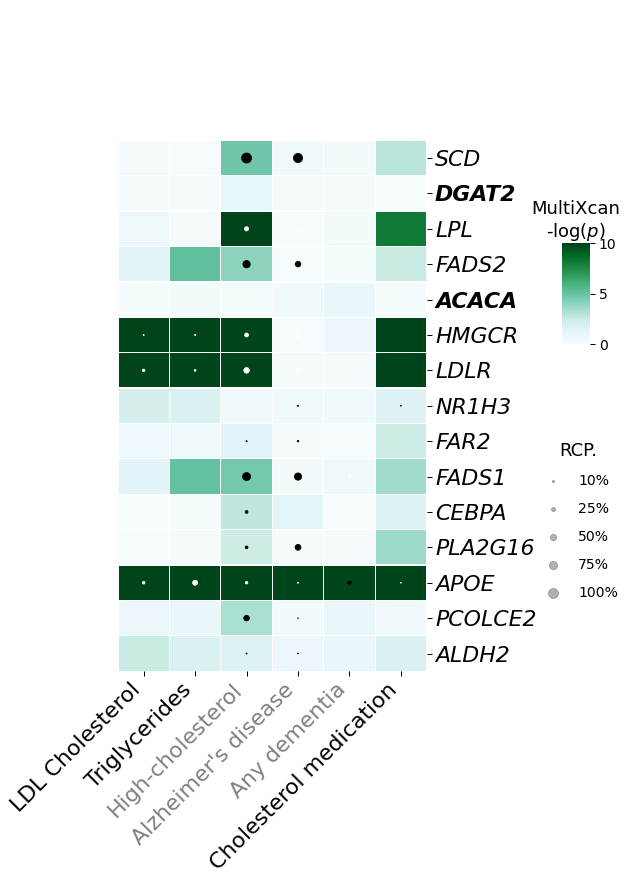

In [130]:
rc = {
    #     "font.size": 9,
    #     "xtick.labelsize": 10,
    #     "ytick.labelsize": 19,
}

with sns.plotting_context("paper", font_scale=2.50, rc=rc):
    g = sns.clustermap(
        data=plot_data,
        vmin=0.0,
        vmax=10.0,
        row_cluster=False,
        col_cluster=False,
        dendrogram_ratio=0.20,
        xticklabels=True,
        yticklabels=True,
        figsize=(8, 14),
        linewidths=0.25,
        cmap="BuGn",
        cbar_pos=(0.95, 0.64, 0.05, 0.10),
    )

    g.ax_heatmap.set_xlabel(None)
    g.ax_heatmap.set_ylabel(None)

    g.ax_heatmap.get_xaxis().set_ticklabels(
        g.ax_heatmap.get_xaxis().get_ticklabels(),
        rotation=45,
        horizontalalignment="right",
    )

    for l in g.ax_heatmap.get_yaxis().get_ticklabels():
        l.set_style("italic")
        if l.get_text() in ("DGAT2", "ACACA"):
            l.set_fontweight("bold")

    for l in g.ax_heatmap.get_xaxis().get_ticklabels():
        if l.get_text() in lipids_traits:
            l.set_color("black")
        elif l.get_text() in diseases_traits:
            l.set_color("gray")
        elif l.get_text() in medications_traits:
            l.set_color("black")
            

    g.ax_heatmap.scatter(
        fastenloc_heatmap_data["traits"].tolist(),
        fastenloc_heatmap_data["genes"].tolist(),
        marker=".",
        s=fastenloc_heatmap_data["marker_size"].tolist(),
        color=fastenloc_heatmap_data["color"].tolist(),
    )

    for rcp in [10, 25, 50, 75, 100]:
        plt.scatter(
            [],
            [],
            marker=".",
            c="k",
            alpha=0.3,
            s=np.power(rcp, n_power),
            label=str(rcp) + "%",
        )
    leg = plt.legend(
        scatterpoints=1,
        frameon=False,
        labelspacing=1,
        loc="center right",
        bbox_to_anchor=(1.90, -2.0, 0.5, 0.5),
        title="RCP.",
        title_fontsize=18,  # rc['ytick.labelsize'],
        fontsize=14,  # rc['ytick.labelsize'],
    )
    plt.setp(leg.get_title(), multialignment="center")

    g.ax_cbar.set_title("MultiXcan\n-log($p$)", fontdict={"fontsize": 18})
    g.ax_cbar.tick_params(labelsize=14)

    output_filepath = OUTPUT_FIGURES_DIR / f"lv{LV_NUMBER_SELECTED}-lv_traits-twas_plot.svg"
    display(output_filepath)
    plt.savefig(
        output_filepath,
        #         dpi=600,
        bbox_inches="tight",
        facecolor="white",
    )

# Show p-values for some genes

In [131]:
_tmp = plot_data.loc["DGAT2"].sort_values()
_tmp = np.power(10, -_tmp)
display(_tmp)

trait_description
Cholesterol medication    0.985034
LDL Cholesterol           0.739952
Triglycerides             0.707148
Alzheimer's disease       0.697446
Any dementia              0.683664
High-cholesterol          0.070069
Name: DGAT2, dtype: float64

In [132]:
_tmp = plot_data.loc["ACACA"].sort_values()
_tmp = np.power(10, -_tmp)
display(_tmp)

trait_description
High-cholesterol          0.621505
Cholesterol medication    0.618065
LDL Cholesterol           0.553760
Triglycerides             0.518586
Alzheimer's disease       0.337064
Any dementia              0.098636
Name: ACACA, dtype: float64

# Show RCP for some genes

In [133]:
_tmp = plot_data2["DGAT2"].sort_values()
_tmp = np.power(10, -_tmp)
display(_tmp)

trait_description
Triglycerides NMR                                                                                                    1.000000
LDL Cholesterol NMR                                                                                                  1.000000
CH2DB NMR                                                                                                            1.000000
alzheimer's disease                                                                                                  1.000000
Any dementia                                                                                                         1.000000
Medication for cholesterol, blood pressure, diabetes, or take exogenous hormones: Cholesterol lowering medication    0.537254
hypercholesterolemia                                                                                                 0.232863
Name: DGAT2, dtype: float64

In [134]:
_tmp = plot_data2["ACACA"].sort_values()
_tmp = np.power(10, -_tmp)
display(_tmp)

trait_description
Triglycerides NMR                                                                                                    1.000000
LDL Cholesterol NMR                                                                                                  1.000000
CH2DB NMR                                                                                                            1.000000
alzheimer's disease                                                                                                  1.000000
Any dementia                                                                                                         1.000000
Medication for cholesterol, blood pressure, diabetes, or take exogenous hormones: Cholesterol lowering medication    0.539759
hypercholesterolemia                                                                                                 0.441367
Name: ACACA, dtype: float64